In [87]:
import pandas as pd

In [88]:
movies = pd.read_csv('../data/movies.csv') 
movies.shape

(9742, 3)

In [89]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [90]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [91]:
movies.describe(include='all')

,movieId,title,genres
count,9742.000000,9742,9742
unique,NaN,9737,951
top,NaN,Emma (1996),Drama
freq,NaN,2,1053
mean,42200.353623,NaN,NaN
std,52160.494854,NaN,NaN
min,1.000000,NaN,NaN
25%,3248.250000,NaN,NaN
50%,7300.000000,NaN,NaN
75%,76232.000000,NaN,NaN


In [92]:
movies.isnull().sum()


movieId    0
title      0
genres     0
dtype: int64

In [93]:
movies.isna().sum()

movieId    0
title      0
genres     0
dtype: int64

In [94]:

movies.nunique()

movieId    9742
title      9737
genres      951
dtype: int64

In [95]:
ratings = pd.read_csv('../data/ratings.csv')
ratings.shape

(100836, 4)

In [96]:
ratings.head(5)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [97]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [98]:
ratings.describe(include='all')

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [99]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [100]:
ratings.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [101]:
ratings.nunique()

userId         610
movieId       9724
rating          10
timestamp    85043
dtype: int64

In [102]:
tags = pd.read_csv('../data/tags.csv')
tags.shape

(3683, 4)

In [103]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [104]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-null   int64 
 2   tag        3683 non-null   object
 3   timestamp  3683 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 115.2+ KB


In [105]:
tags.describe(include='all')

,userId,movieId,tag,timestamp
count,3683.000000,3683.000000,3683,3.683000e+03
unique,NaN,NaN,1589,NaN
top,NaN,NaN,In Netflix queue,NaN
freq,NaN,NaN,131,NaN
mean,431.149335,27252.013576,NaN,1.320032e+09
std,158.472553,43490.558803,NaN,1.721025e+08
min,2.000000,1.000000,NaN,1.137179e+09
25%,424.000000,1262.500000,NaN,1.137521e+09
50%,474.000000,4454.000000,NaN,1.269833e+09
75%,477.000000,39263.000000,NaN,1.498457e+09


In [106]:
tags.isnull().sum()

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

In [107]:
tags.isna().sum()

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

In [108]:
tags.nunique()

userId         58
movieId      1572
tag          1589
timestamp    3411
dtype: int64

# PADRONIZAÇÃO

In [109]:
import re

import re

def to_snake_case(col):
    col = col.strip()
    # separa camelCase
    col = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col)
    # lowercase
    col = col.lower()
    # troca espaços e separadores
    col = re.sub(r'[\s\-/]+', '_', col)
    # remove caracteres especiais
    col = re.sub(r'[^a-z0-9_]', '', col)
    # remove "__"
    col = re.sub(r'_+', '_', col)
    # remove "_" começo/fim
    col = col.strip('_')

    return col

movies.columns = [to_snake_case(col) for col in movies.columns]
ratings.columns = [to_snake_case(col) for col in ratings.columns]
tags.columns = [to_snake_case(col) for col in tags.columns]

In [110]:
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [111]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [112]:
tags.head()

,user_id,movie_id,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


# JOIN - Movies & Rating

In [113]:
df_moviesRating = ratings.merge(
    movies,
    on="movie_id",
    how="left"
)


In [114]:
df_moviesRating.head()

,user_id,movie_id,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# ANALISES

In [115]:
print('Quantidade de filmes:', df_moviesRating["movie_id"].nunique())
print('Quantidade de categorias de filmes que mais apareceram:', df_moviesRating["genres"].value_counts().head(3))

Quantidade de filmes: 9724
Quantidade de categorias de filmes que mais apareceram: genres
Comedy            7196
Drama             6291
Comedy|Romance    3967
Name: count, dtype: int64


In [116]:
print('media de rating por filme:', df_moviesRating.groupby('title')['rating'].mean())

media de rating por filme: title
'71 (2014)                                   4.000000
'Hellboy': The Seeds of Creation (2004)      4.000000
'Round Midnight (1986)                       3.500000
'Salem's Lot (2004)                          5.000000
'Til There Was You (1997)                    4.000000
                                               ...   
eXistenZ (1999)                              3.863636
xXx (2002)                                   2.770833
xXx: State of the Union (2005)               2.000000
¡Three Amigos! (1986)                        3.134615
À nous la liberté (Freedom for Us) (1931)    1.000000
Name: rating, Length: 9719, dtype: float64


In [117]:
print('Quantidade de usuarios:', df_moviesRating["user_id"].nunique())

Quantidade de usuarios: 610


In [118]:
print('media de rating:', df_moviesRating['rating'].mean())

media de rating: 3.501556983616962


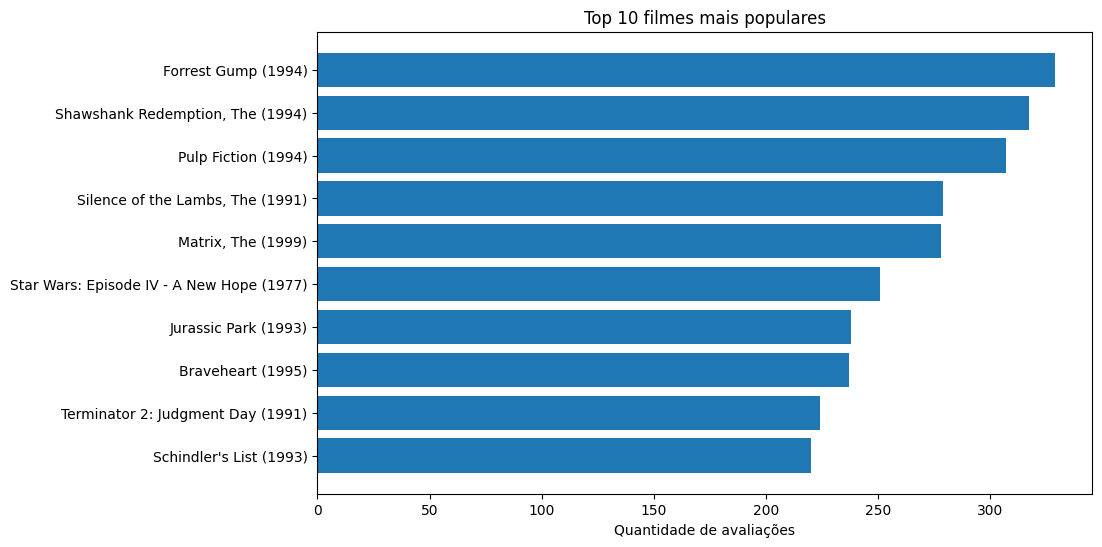

In [119]:
import matplotlib.pyplot as plt

popular_movies = (
    df_moviesRating["title"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    popular_movies.index,
    popular_movies.values
)

plt.xlabel("Quantidade de avaliações")
plt.title("Top 10 filmes mais populares")

plt.gca().invert_yaxis()

plt.show()

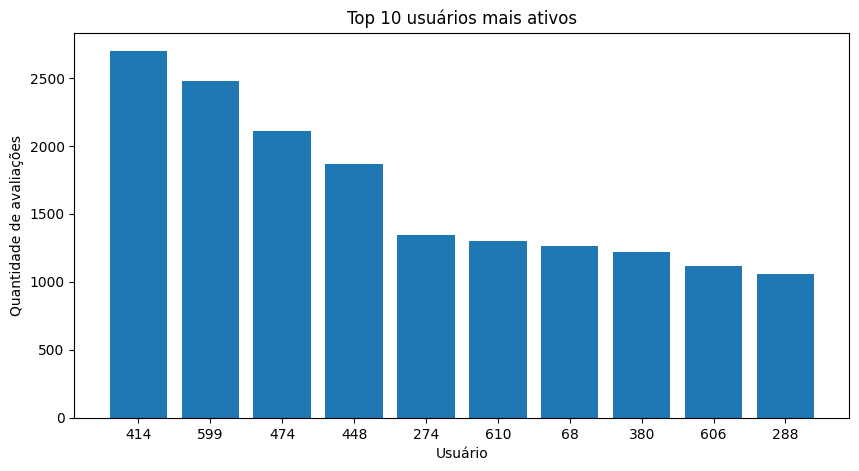

In [120]:
import matplotlib.pyplot as plt

top_users = (
    df_moviesRating["user_id"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.bar(
    top_users.index.astype(str),
    top_users.values
)

plt.xlabel("Usuário")
plt.ylabel("Quantidade de avaliações")
plt.title("Top 10 usuários mais ativos")

plt.show()

In [121]:
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [122]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [123]:
tags.head()

,user_id,movie_id,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [124]:
links = pd.read_csv('../data/links.csv')
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [125]:
df_moviesRating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    100836 non-null  int64  
 1   movie_id   100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


In [126]:
df_moviesRating.head(10)

,user_id,movie_id,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
5,1,70,3.0,964982400,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller
6,1,101,5.0,964980868,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance
7,1,110,4.0,964982176,Braveheart (1995),Action|Drama|War
8,1,151,5.0,964984041,Rob Roy (1995),Action|Drama|Romance|War
9,1,157,5.0,964984100,Canadian Bacon (1995),Comedy|War


In [127]:
df_moviesRating.describe(include="all")

,user_id,movie_id,rating,timestamp,title,genres
count,100836.000000,100836.000000,100836.000000,1.008360e+05,100836,100836
unique,NaN,NaN,NaN,NaN,9719,951
top,NaN,NaN,NaN,NaN,Forrest Gump (1994),Comedy
freq,NaN,NaN,NaN,NaN,329,7196
mean,326.127564,19435.295718,3.501557,1.205946e+09,NaN,NaN
std,182.618491,35530.987199,1.042529,2.162610e+08,NaN,NaN
min,1.000000,1.000000,0.500000,8.281246e+08,NaN,NaN
25%,177.000000,1199.000000,3.000000,1.019124e+09,NaN,NaN
50%,325.000000,2991.000000,3.500000,1.186087e+09,NaN,NaN
75%,477.000000,8122.000000,4.000000,1.435994e+09,NaN,NaN


In [128]:
df_moviesRating.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [129]:
df_moviesRating["timestamp"] = pd.to_datetime(
    df_moviesRating["timestamp"],
    unit="s"
)

In [130]:
df_moviesRating["rating_year"] = df_moviesRating["timestamp"].dt.year

In [131]:
df_moviesRating["movie_year"] = df_moviesRating["title"].str.extract(r"\((\d{4})\)")

In [132]:
df_moviesRating["movie_year"] = df_moviesRating["movie_year"].astype(float)

In [133]:
ratings_by_year = df_moviesRating["rating_year"].value_counts().sort_index()

In [134]:
movies_by_year = df_moviesRating["movie_year"].value_counts().sort_index()

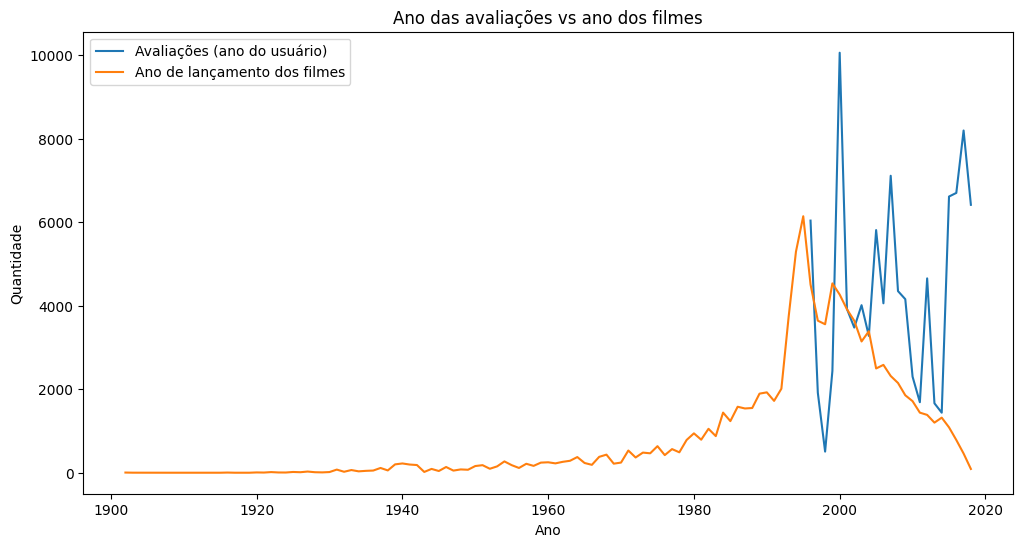

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(ratings_by_year.index, ratings_by_year.values, label="Avaliações (ano do usuário)")
plt.plot(movies_by_year.index, movies_by_year.values, label="Ano de lançamento dos filmes")

plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.title("Ano das avaliações vs ano dos filmes")
plt.legend()

plt.show()

In [136]:
df_moviesRating.head()

,user_id,movie_id,rating,timestamp,title,genres,rating_year,movie_year
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2000,1995.0
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance,2000,1995.0
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller,2000,1995.0
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,2000,1995.0
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,2000,1995.0


In [137]:
max_date = df_moviesRating["timestamp"].max()

cutoff = max_date - pd.DateOffset(months=2)

In [138]:
recent = df_moviesRating[df_moviesRating["timestamp"] >= cutoff]
past = df_moviesRating[df_moviesRating["timestamp"] < cutoff]

In [139]:
recent_exploded = recent.assign(
    genre=recent["genres"].str.split("|")
).explode("genre")

past_exploded = past.assign(
    genre=past["genres"].str.split("|")
).explode("genre")

In [140]:
df_moviesRating.head()

,user_id,movie_id,rating,timestamp,title,genres,rating_year,movie_year
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2000,1995.0
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance,2000,1995.0
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller,2000,1995.0
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,2000,1995.0
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,2000,1995.0


In [141]:
df_moviesRating[
    (df_moviesRating["movie_id"] == 1)
]

,user_id,movie_id,rating,timestamp,title,genres,rating_year,movie_year
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2000,1995.0
516,5,1,4.0,1996-11-08 06:36:02,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1996,1995.0
874,7,1,4.5,2005-01-25 06:52:26,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2005,1995.0
1434,15,1,2.5,2017-11-13 12:59:30,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2017,1995.0
1667,17,1,4.5,2011-05-18 05:28:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2011,1995.0
...,...,...,...,...,...,...,...,...
97364,606,1,2.5,2012-10-01 09:15:50,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2012,1995.0
98479,607,1,4.0,2000-07-28 00:27:13,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2000,1995.0
98666,608,1,2.5,2005-05-29 23:11:07,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2005,1995.0
99497,609,1,3.0,1996-11-05 19:10:25,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1996,1995.0


In [142]:
user_id = 3

recent_user = recent_exploded[recent_exploded["user_id"] == user_id]
past_user = past_exploded[past_exploded["user_id"] == user_id]

In [143]:
past_genres = past_user["genre"].value_counts(normalize=True)

In [144]:
recent_genres = recent_user["genre"].value_counts(normalize=True)

In [145]:
comparison = pd.DataFrame({
    "past": past_genres,
    "recent": recent_genres
}).fillna(0)

print(comparison)

               past  recent
genre                      
Action     0.130841     0.0
Adventure  0.102804     0.0
Animation  0.037383     0.0
Children   0.046729     0.0
Comedy     0.084112     0.0
Crime      0.018692     0.0
Drama      0.149533     0.0
Fantasy    0.037383     0.0
Horror     0.074766     0.0
Musical    0.009346     0.0
Mystery    0.009346     0.0
Romance    0.046729     0.0
Sci-Fi     0.140187     0.0
Thriller   0.065421     0.0
War        0.046729     0.0


In [146]:
ratings[
    (ratings["movie_id"] == 60756) &
    (ratings["user_id"] == 2)
]

,user_id,movie_id,rating,timestamp
241,2,60756,5.0,1445714980


In [147]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


# Outliers

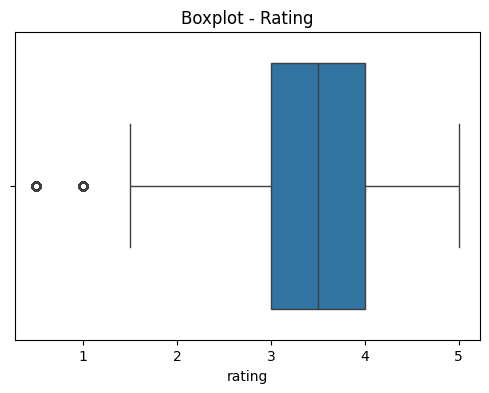

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.boxplot(
    x=df_moviesRating["rating"]
)

plt.title("Boxplot - Rating")
plt.show()

In [149]:
Q1 = df_moviesRating["rating"].quantile(0.25)
Q3 = df_moviesRating["rating"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_moviesRating[
    (df_moviesRating["rating"] < lower) |
    (df_moviesRating["rating"] > upper)
]

print(outliers.head())

     user_id  movie_id  rating           timestamp  \
205        1      3176     1.0 2000-07-30 18:58:24   
261        3        31     0.5 2011-05-27 02:32:58   
262        3       527     0.5 2011-05-27 02:44:35   
263        3       647     0.5 2011-05-27 02:33:39   
264        3       688     0.5 2011-05-27 02:43:48   

                               title                       genres  \
205  Talented Mr. Ripley, The (1999)       Drama|Mystery|Thriller   
261           Dangerous Minds (1995)                        Drama   
262          Schindler's List (1993)                    Drama|War   
263        Courage Under Fire (1996)       Action|Crime|Drama|War   
264      Operation Dumbo Drop (1995)  Action|Adventure|Comedy|War   

     rating_year  movie_year  
205         2000      1999.0  
261         2011      1995.0  
262         2011      1993.0  
263         2011      1996.0  
264         2011      1995.0  


In [150]:
user_activity = (
    df_moviesRating
    .groupby("user_id")
    .size()
    .reset_index(name="total_ratings")
)

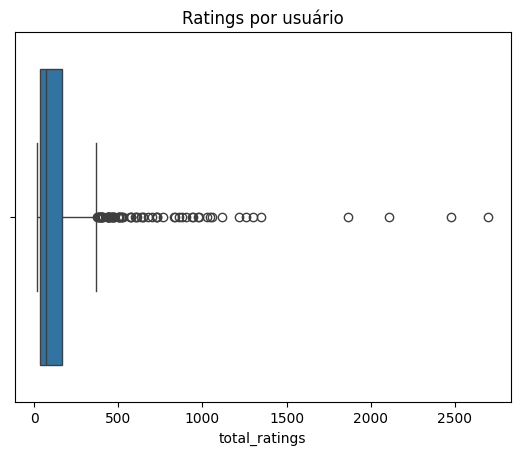

In [151]:
sns.boxplot(
    x=user_activity["total_ratings"]
)

plt.title("Ratings por usuário")
plt.show()

In [152]:
Q1 = user_activity["total_ratings"].quantile(.25)
Q3 = user_activity["total_ratings"].quantile(.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

user_outliers = user_activity[
    user_activity["total_ratings"] > upper
]

print(user_outliers.head())

    user_id  total_ratings
17       18            502
18       19            703
20       21            443
27       28            570
41       42            440


In [153]:
movie_popularity = (
    df_moviesRating
    .groupby("title")
    .size()
    .reset_index(name="total_ratings")
)

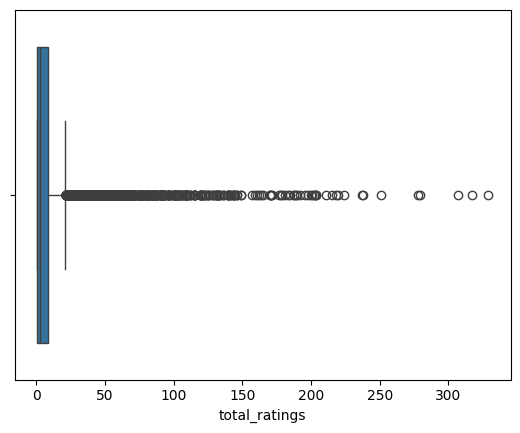

In [154]:
sns.boxplot(
    x=movie_popularity["total_ratings"]
)

plt.show()

In [155]:
movie_outliers = movie_popularity[
    movie_popularity["total_ratings"] > upper
]

In [156]:
df_moviesRating["movie_year"] = (
    df_moviesRating["title"]
    .str.extract(r"\((\d{4})\)")
    .astype(float)
)

In [157]:
print(
    df_moviesRating["movie_year"].describe()
)

count    100818.000000
mean       1994.444990
std          14.361424
min        1902.000000
25%        1990.000000
50%        1997.000000
75%        2003.000000
max        2018.000000
Name: movie_year, dtype: float64


In [158]:
df_moviesRating[
    df_moviesRating["movie_year"] < 1900
]

,user_id,movie_id,rating,timestamp,title,genres,rating_year,movie_year


In [159]:
df_moviesRating[
    df_moviesRating["movie_year"] > 2026
]

,user_id,movie_id,rating,timestamp,title,genres,rating_year,movie_year


# JOIN ratings + movies + tags

In [ ]:
df_movies_rating = df_moviesRating.merge(
    tags,
    on=["user_id", "movie_id"],
    how="left"
)

In [161]:
df_movies_rating.head()

,user_id,movie_id,rating,timestamp_x,title,genres,rating_year,movie_year,tag,timestamp_y
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2000,1995.0,NaN,NaN
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance,2000,1995.0,NaN,NaN
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller,2000,1995.0,NaN,NaN
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,2000,1995.0,NaN,NaN
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,2000,1995.0,NaN,NaN


In [162]:
print(tags.shape)

(3683, 4)


In [163]:
print(
    df_movies_rating["tag"]
    .isna()
    .sum()
)

99201


In [164]:
print(tags.columns)

Index(['user_id', 'movie_id', 'tag', 'timestamp'], dtype='object')
